In [45]:
# For group members
# Run this cell once. 
# If your env already has these packages, it may say they are already installed.
# otherwise it will install 
!pip install torch torchvision torchaudio
!pip install kagglehub

from pathlib import Path
import random
import json
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#print("Torch version:", torch.__version__)
SEED = 67
#just ensuring our machine is using the CPU instead of GPU
#just tells torth where to do all our math
DEVICE = torch.device("cpu")
#double checking
print("Using device:", DEVICE)

Using device: cpu


In [46]:
path = kagglehub.dataset_download("ahemateja19bec1025/traffic-sign-dataset-classification")
print("Dataset downloaded to:", path)

traffic_data_dir = Path(path) / "traffic_Data"

DATA_DIR = traffic_data_dir / "DATA"
TEST_DIR = traffic_data_dir / "TEST"

print("Using traffic_Data folder:", traffic_data_dir)
print("DATA exists:", DATA_DIR.exists())
print("TEST exists:", TEST_DIR.exists())
labels_df = pd.read_csv("labels.csv")
labels_df.head()

Dataset downloaded to: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2
Using traffic_Data folder: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data
DATA exists: True
TEST exists: True


,ClassId,Name
0,0,Speed limit (5km/h)
1,1,Speed limit (15km/h)
2,2,Speed limit (30km/h)
3,3,Speed limit (40km/h)
4,4,Speed limit (50km/h)


In [47]:
# Used ChatGPT to help group the 58 original traffic sign classes
# into fewer meaningful categories. Unknown classes are dropped.

group_map = {
    # 0: Speed limit signs
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 18: 0, 19: 0,

    # 1: Prohibited direction / movement signs
    8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 15: 1,

    # 2: Other prohibited signs
    14: 2, 16: 2, 17: 2, 54: 2, 55: 2,

    # 3: Mandatory direction signs
    20: 3, 21: 3, 22: 3, 23: 3, 24: 3, 25: 3, 26: 3, 27: 3,
    31: 3, 43: 3, 44: 3,

    # 4: Crossing / road user warning signs
    28: 4, 30: 4, 35: 4, 36: 4, 37: 4, 47: 4,

    # 5: Road hazard / road condition warning signs
    32: 5, 34: 5, 38: 5, 39: 5, 46: 5, 48: 5, 50: 5, 51: 5,

    # 6: Traffic control / other regulatory signs
    29: 6, 33: 6, 53: 6,
}

unknown_ids = [40, 41, 42, 45, 49, 52, 56, 57]

class_names = {
    0: "Speed limit",
    1: "Prohibited direction",
    2: "Other prohibited",
    3: "Mandatory direction",
    4: "Crossing / road user warning",
    5: "Road hazard / condition warning",
    6: "Traffic control / other regulatory",
}
# Drop unknown rows from the label table and add grouped labels.
labels_clean = labels_df[~labels_df["ClassId"].isin(unknown_ids)].copy()
labels_clean["GroupedClassId"] = labels_clean["ClassId"].map(group_map)
labels_clean["GroupedName"] = labels_clean["GroupedClassId"].map(class_names)

print("Original number of label rows:", len(labels_df))
print("Number after dropping unknown labels:", len(labels_clean))
print("Missing grouped labels:", labels_clean["GroupedClassId"].isna().sum())

labels_clean.head(15)

Original number of label rows: 58
Number after dropping unknown labels: 50
Missing grouped labels: 0


,ClassId,Name,GroupedClassId,GroupedName
0,0,Speed limit (5km/h),0,Speed limit
1,1,Speed limit (15km/h),0,Speed limit
2,2,Speed limit (30km/h),0,Speed limit
3,3,Speed limit (40km/h),0,Speed limit
4,4,Speed limit (50km/h),0,Speed limit
5,5,Speed limit (60km/h),0,Speed limit
6,6,Speed limit (70km/h),0,Speed limit
7,7,speed limit (80km/h),0,Speed limit
8,8,Dont Go straight or left,1,Prohibited direction
9,9,Dont Go straight or Right,1,Prohibited direction


In [48]:
# Show how many original sign labels are in each new group.
labels_clean.groupby(["GroupedClassId", "GroupedName"])["ClassId"].count().rename("Number of original labels")
path = kagglehub.dataset_download("ahemateja19bec1025/traffic-sign-dataset-classification")
print("Dataset path:", path)

Dataset path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2


In [49]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def build_labeled_image_df_from_folders(root_dir):
    rows = []

    for class_folder in sorted(root_dir.iterdir()):
        if class_folder.is_dir() and class_folder.name.isdigit():
            class_id = int(class_folder.name)

            for image_path in class_folder.rglob("*"):
                if image_path.suffix.lower() in image_extensions:
                    rows.append({
                        "image_path": str(image_path),
                        "ClassId": class_id
                    })

    return pd.DataFrame(rows)

In [50]:
image_df = build_labeled_image_df_from_folders(DATA_DIR)

if image_df.empty:
    raise ValueError("No images were found in DATA_DIR. Check the folder path.")

# Drop unknown classes
image_df = image_df[~image_df["ClassId"].isin(unknown_ids)].copy()

# Map old labels to grouped labels
image_df["GroupedClassId"] = image_df["ClassId"].map(group_map)
image_df["GroupedName"] = image_df["GroupedClassId"].map(class_names)

# Remove anything that did not map correctly
image_df = image_df.dropna(subset=["GroupedClassId"]).copy()
image_df["GroupedClassId"] = image_df["GroupedClassId"].astype(int)

print("Total usable DATA images after dropping unknown classes:", len(image_df))
print("Grouped class counts:")
print(image_df["GroupedName"].value_counts())

image_df.head()

Total usable DATA images after dropping unknown classes: 3870
Grouped class counts:
GroupedName
Speed limit                           1032
Other prohibited                       886
Crossing / road user warning           862
Mandatory direction                    472
Prohibited direction                   372
Road hazard / condition warning        196
Traffic control / other regulatory      50
Name: count, dtype: int64


,image_path,ClassId,GroupedClassId,GroupedName
0,/Users/thomas/.cache/kagglehub/datasets/ahemat...,0,0,Speed limit
1,/Users/thomas/.cache/kagglehub/datasets/ahemat...,0,0,Speed limit
2,/Users/thomas/.cache/kagglehub/datasets/ahemat...,0,0,Speed limit
3,/Users/thomas/.cache/kagglehub/datasets/ahemat...,0,0,Speed limit
4,/Users/thomas/.cache/kagglehub/datasets/ahemat...,0,0,Speed limit


In [51]:
#double checking that all the unknown classes are gone from our data
print("Unknown rows remaining:", image_df["ClassId"].isin(unknown_ids).sum())
print("Grouped labels present:", sorted(image_df["GroupedClassId"].unique()))

Unknown rows remaining: 0
Grouped labels present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]



- 80% training 20% validation
- The whole TEST folder from kaggle is used for test

In [52]:
train_df, val_df = train_test_split(
    image_df,
    test_size=0.20,
    random_state=SEED,
    stratify=image_df["GroupedClassId"]
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))

split_counts = pd.DataFrame({
    "train": train_df["GroupedName"].value_counts(),
    "validation": val_df["GroupedName"].value_counts(),
}).fillna(0).astype(int)

split_counts

Train images: 3096
Validation images: 774


,train,validation
GroupedName,,
Speed limit,826,206
Other prohibited,709,177
Crossing / road user warning,690,172
Mandatory direction,377,95
Prohibited direction,297,75
Road hazard / condition warning,157,39
Traffic control / other regulatory,40,10


In [55]:
# print("TEST_DIR:", TEST_DIR)
# print("TEST exists:", TEST_DIR.exists())

# print("\nFirst 20 things inside TEST:")
# for item in list(TEST_DIR.iterdir())[:20]:
#     print(item)
import re

def build_labeled_test_df_from_filenames(root_dir):
    rows = []

    for image_path in root_dir.rglob("*"):
        if image_path.suffix.lower() in image_extensions:
            filename = image_path.name

            # Get the first number before the first underscore
            match = re.match(r"^(\d+)_", filename)

            if match:
                class_id = int(match.group(1))

                rows.append({
                    "image_path": str(image_path),
                    "ClassId": class_id
                })

    return pd.DataFrame(rows)

In [56]:
test_df = build_labeled_test_df_from_filenames(TEST_DIR)

if test_df.empty:
    raise ValueError("No labeled images were found in TEST_DIR. Check filename format.")

# Drop unknown classes
test_df = test_df[~test_df["ClassId"].isin(unknown_ids)].copy()

# Map old labels to grouped labels
test_df["GroupedClassId"] = test_df["ClassId"].map(group_map)
test_df["GroupedName"] = test_df["GroupedClassId"].map(class_names)

# Remove anything that did not map correctly
test_df = test_df.dropna(subset=["GroupedClassId"]).copy()
test_df["GroupedClassId"] = test_df["GroupedClassId"].astype(int)

print("Final TEST images after dropping unknown classes:", len(test_df))
print("TEST grouped class counts:")
print(test_df["GroupedName"].value_counts())

test_df.head()

Final TEST images after dropping unknown classes: 1842
TEST grouped class counts:
GroupedName
Other prohibited                      406
Mandatory direction                   376
Speed limit                           358
Prohibited direction                  354
Crossing / road user warning          196
Road hazard / condition warning       124
Traffic control / other regulatory     28
Name: count, dtype: int64


,image_path,ClassId,GroupedClassId,GroupedName
0,/Users/thomas/.cache/kagglehub/datasets/ahemat...,26,3,Mandatory direction
1,/Users/thomas/.cache/kagglehub/datasets/ahemat...,36,4,Crossing / road user warning
2,/Users/thomas/.cache/kagglehub/datasets/ahemat...,26,3,Mandatory direction
3,/Users/thomas/.cache/kagglehub/datasets/ahemat...,50,5,Road hazard / condition warning
4,/Users/thomas/.cache/kagglehub/datasets/ahemat...,54,2,Other prohibited


In [57]:
class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["GroupedClassId"])
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, label


IMG_SIZE = 224
BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


#changes pixels from 0-255 to 0-1
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


train_dataset = TrafficSignDataset(train_df, transform=train_transform)
val_dataset = TrafficSignDataset(val_df, transform=val_test_transform)
test_dataset = TrafficSignDataset(test_df, transform=val_test_transform)

# CPU-only setting
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

print("Dataloaders ready.")

Dataloaders ready.


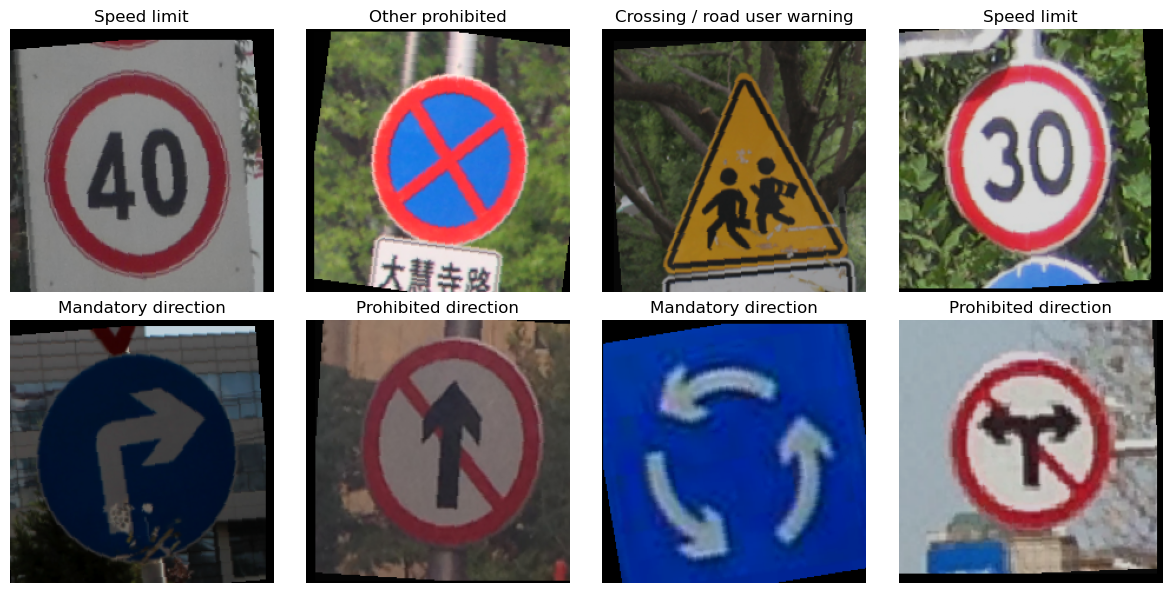

In [58]:
def denormalize(tensor):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    plt.imshow(img)
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
NUM_CLASSES = 7

try:
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    print("Loaded pretrained ResNet18 weights.")
except Exception as e:
    print("Could not load pretrained weights. Using randomly initialized ResNet18.")
    print("Reason:", e)
    model = models.resnet18(weights=None)

# Freeze all layers first.
for param in model.parameters():
    param.requires_grad = False

# Fine-tune the last ResNet block.
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer with a 4-class classifier.
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.30), #should reduce overfitting
    nn.Linear(in_features, NUM_CLASSES)
)

# trainable_params = weights that will update during training
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# total_params = all weights in the model
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Loaded pretrained ResNet18 weights.
Trainable parameters: 8,397,319 / 11,180,103


In [60]:
# Loss and optimizer
# Class weights help if one grouped class has many more images than another.

class_counts = train_df["GroupedClassId"].value_counts().sort_index()
class_weights = len(train_df) / (NUM_CLASSES * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)

EPOCHS = 8
print("Class weights:", class_weights.to_dict())

Class weights: {0: 0.5354548599100657, 1: 1.4891774891774892, 2: 0.6238162401773121, 3: 1.1731716559302767, 4: 0.6409937888198758, 5: 2.8171064604185623, 6: 11.057142857142857}


In [61]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in dataloader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().numpy())
        all_labels.extend(labels.numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

#read about torch.no_grad about making this run faster
@torch.no_grad() #https://www.geeksforgeeks.org/python/what-is-with-torch-no_grad-in-pytorch/ 
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in dataloader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [62]:
history = []
best_val_loss = float("inf")
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
    )

if best_model_state is not None:
    model.load_state_dict(best_model_state)

history_df = pd.DataFrame(history)
history_df

Epoch 01/8 | Train loss: 0.4377 | Train acc: 0.8731 | Val loss: 0.0765 | Val acc: 0.9845
Epoch 02/8 | Train loss: 0.0491 | Train acc: 0.9932 | Val loss: 0.0215 | Val acc: 0.9961
Epoch 03/8 | Train loss: 0.0214 | Train acc: 0.9974 | Val loss: 0.0076 | Val acc: 0.9987
Epoch 04/8 | Train loss: 0.0118 | Train acc: 0.9997 | Val loss: 0.0043 | Val acc: 1.0000
Epoch 05/8 | Train loss: 0.0065 | Train acc: 0.9994 | Val loss: 0.0033 | Val acc: 0.9987
Epoch 06/8 | Train loss: 0.0041 | Train acc: 1.0000 | Val loss: 0.0016 | Val acc: 1.0000
Epoch 07/8 | Train loss: 0.0027 | Train acc: 0.9997 | Val loss: 0.0012 | Val acc: 1.0000
Epoch 08/8 | Train loss: 0.0073 | Train acc: 0.9987 | Val loss: 0.0057 | Val acc: 0.9974


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.437689,0.873062,0.076451,0.984496
1,2,0.049099,0.993217,0.021506,0.996124
2,3,0.021406,0.997416,0.007608,0.998708
3,4,0.011793,0.999677,0.004297,1.000000
4,5,0.006477,0.999354,0.003294,0.998708
5,6,0.004068,1.000000,0.001583,1.000000
6,7,0.002710,0.999677,0.001205,1.000000
7,8,0.007349,0.998708,0.005665,0.997416


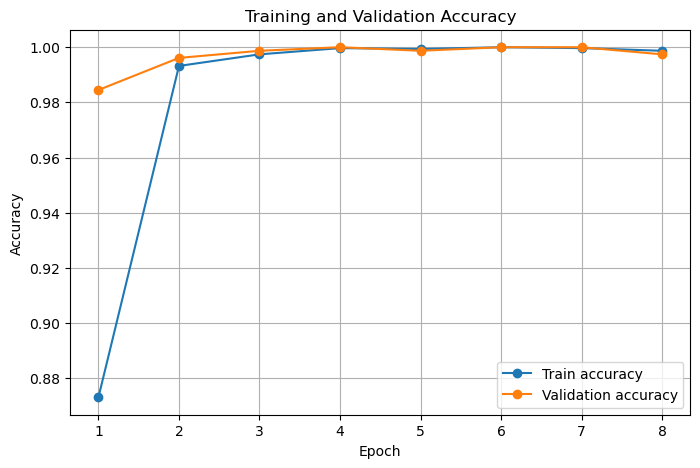

In [ ]:
# Plot training history

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Final Eval

In [65]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=[class_names[i] for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0
)

print(report)

Test loss: 0.0811
Test accuracy: 0.9772
                                    precision    recall  f1-score   support

                       Speed limit     0.9779    0.9888    0.9833       358
              Prohibited direction     1.0000    0.9718    0.9857       354
                  Other prohibited     0.9853    0.9901    0.9877       406
               Mandatory direction     0.9783    0.9574    0.9677       376
      Crossing / road user warning     1.0000    0.9592    0.9792       196
   Road hazard / condition warning     0.8732    1.0000    0.9323       124
Traffic control / other regulatory     0.9333    1.0000    0.9655        28

                          accuracy                         0.9772      1842
                         macro avg     0.9640    0.9811    0.9716      1842
                      weighted avg     0.9785    0.9772    0.9774      1842



In [66]:
val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion)

print("Validation accuracy:", val_acc)

print(pd.crosstab(
    pd.Series(y_true, name="Actual"),
    pd.Series(y_pred, name="Predicted")
))

Validation accuracy: 1.0
Predicted    0   1    2   3    4   5   6
Actual                                  
0          206   0    0   0    0   0   0
1            0  75    0   0    0   0   0
2            0   0  177   0    0   0   0
3            0   0    0  95    0   0   0
4            0   0    0   0  172   0   0
5            0   0    0   0    0  39   0
6            0   0    0   0    0   0  10


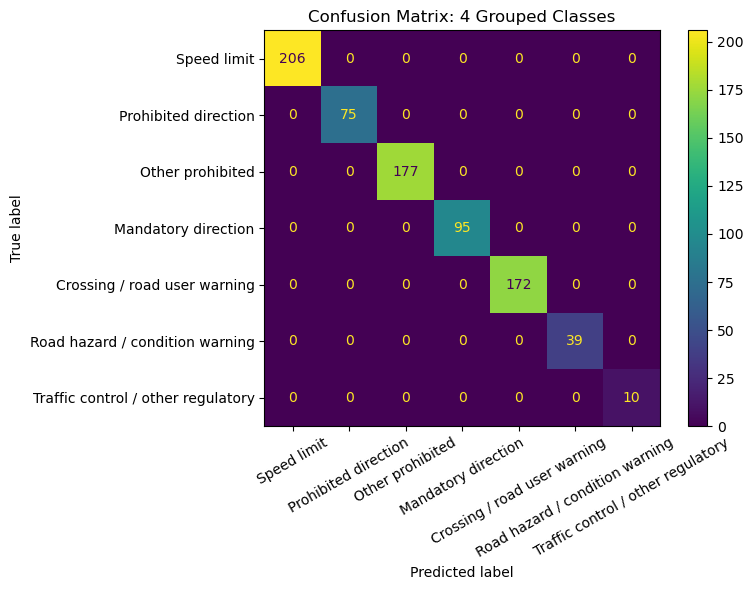

In [67]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[class_names[i] for i in range(NUM_CLASSES)],
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix: 4 Grouped Classes")
plt.tight_layout()
plt.show()

In [70]:
MODEL_PATH = Path("traffic_sign_grouped_resnet18.pt")
METADATA_PATH = Path("traffic_sign_grouped_metadata.json")

checkpoint = {
    "model_name": "resnet18",
    "model_state_dict": model.cpu().state_dict(),
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "group_map": group_map,
    "unknown_ids": unknown_ids,
    "img_size": IMG_SIZE,
    "imagenet_mean": imagenet_mean,
    "imagenet_std": imagenet_std,
}

torch.save(checkpoint, MODEL_PATH)

with open(METADATA_PATH, "w") as f:
    json.dump({
        "class_names": class_names,
        "group_map": group_map,
        "unknown_ids": unknown_ids,
        "img_size": IMG_SIZE,
        "imagenet_mean": imagenet_mean,
        "imagenet_std": imagenet_std,
    }, f, indent=2)

model = model.to(DEVICE)

print("Saved model to:", MODEL_PATH.resolve())
print("Saved metadata to:", METADATA_PATH.resolve())

Saved model to: /Users/thomas/Desktop/SmartSpin/ProjectT/traffic_sign_grouped_resnet18.pt
Saved metadata to: /Users/thomas/Desktop/SmartSpin/ProjectT/traffic_sign_grouped_metadata.json


Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/007_1_0010_1_j.png
True group: Speed limit
Predicted group: Speed limit
Probabilities:
  Speed limit: 0.9978
  Prohibited direction: 0.0002
  Other prohibited: 0.0004
  Mandatory direction: 0.0004
  Crossing / road user warning: 0.0006
  Road hazard / condition warning: 0.0002
  Traffic control / other regulatory: 0.0002


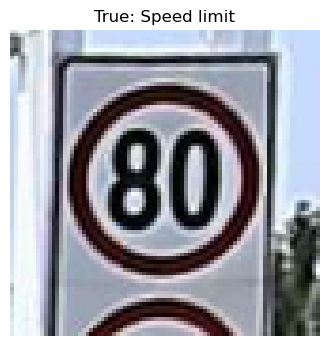

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/004_1_0022_1_j.png
True group: Speed limit
Predicted group: Speed limit
Probabilities:
  Speed limit: 0.9942
  Prohibited direction: 0.0011
  Other prohibited: 0.0010
  Mandatory direction: 0.0012
  Crossing / road user warning: 0.0014
  Road hazard / condition warning: 0.0007
  Traffic control / other regulatory: 0.0004


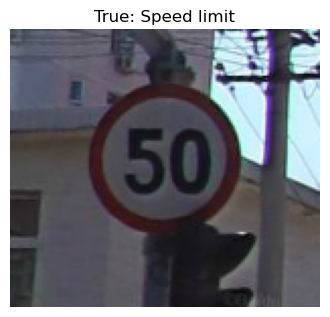

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/026_1_0007_1_j.png
True group: Mandatory direction
Predicted group: Mandatory direction
Probabilities:
  Speed limit: 0.0000
  Prohibited direction: 0.0001
  Other prohibited: 0.0002
  Mandatory direction: 0.9995
  Crossing / road user warning: 0.0000
  Road hazard / condition warning: 0.0000
  Traffic control / other regulatory: 0.0001


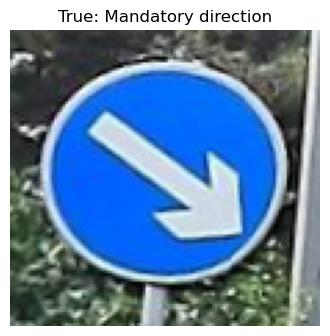

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/003_0036.png
True group: Speed limit
Predicted group: Speed limit
Probabilities:
  Speed limit: 0.9755
  Prohibited direction: 0.0103
  Other prohibited: 0.0017
  Mandatory direction: 0.0032
  Crossing / road user warning: 0.0021
  Road hazard / condition warning: 0.0031
  Traffic control / other regulatory: 0.0040


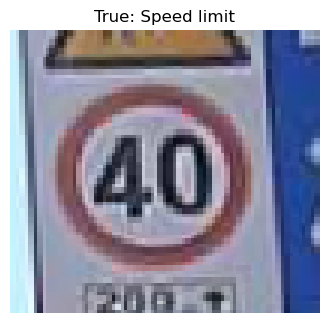

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/050_1_0003_1_j.png
True group: Road hazard / condition warning
Predicted group: Road hazard / condition warning
Probabilities:
  Speed limit: 0.0010
  Prohibited direction: 0.0002
  Other prohibited: 0.0046
  Mandatory direction: 0.0092
  Crossing / road user warning: 0.0041
  Road hazard / condition warning: 0.9800
  Traffic control / other regulatory: 0.0009


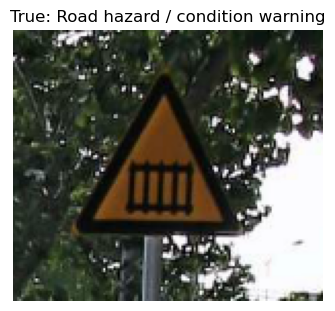

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/005_0023_j.png
True group: Speed limit
Predicted group: Speed limit
Probabilities:
  Speed limit: 0.9989
  Prohibited direction: 0.0001
  Other prohibited: 0.0002
  Mandatory direction: 0.0002
  Crossing / road user warning: 0.0002
  Road hazard / condition warning: 0.0002
  Traffic control / other regulatory: 0.0002


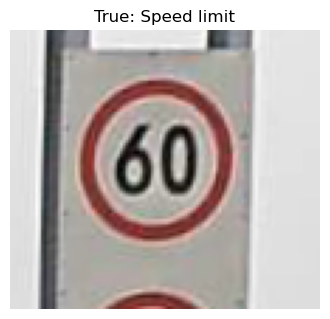

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/026_0066_j.png
True group: Mandatory direction
Predicted group: Mandatory direction
Probabilities:
  Speed limit: 0.0000
  Prohibited direction: 0.0000
  Other prohibited: 0.0000
  Mandatory direction: 0.9999
  Crossing / road user warning: 0.0000
  Road hazard / condition warning: 0.0000
  Traffic control / other regulatory: 0.0000


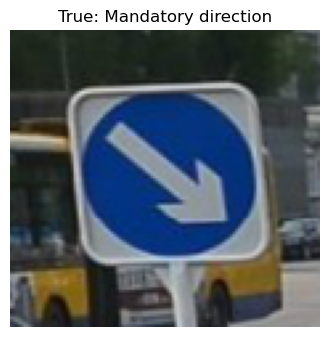

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/017_0016_j.png
True group: Other prohibited
Predicted group: Other prohibited
Probabilities:
  Speed limit: 0.0337
  Prohibited direction: 0.0201
  Other prohibited: 0.9169
  Mandatory direction: 0.0085
  Crossing / road user warning: 0.0039
  Road hazard / condition warning: 0.0064
  Traffic control / other regulatory: 0.0104


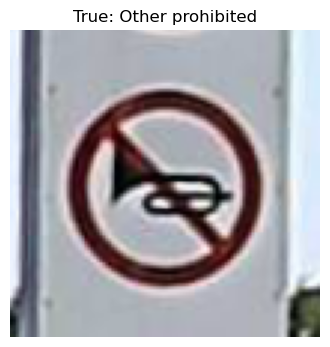

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/004_1_0027_1_j.png
True group: Speed limit
Predicted group: Speed limit
Probabilities:
  Speed limit: 0.9985
  Prohibited direction: 0.0001
  Other prohibited: 0.0011
  Mandatory direction: 0.0000
  Crossing / road user warning: 0.0002
  Road hazard / condition warning: 0.0001
  Traffic control / other regulatory: 0.0001


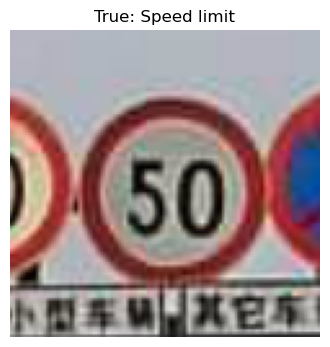

Image path: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/TEST/008_0006_j.png
True group: Prohibited direction
Predicted group: Prohibited direction
Probabilities:
  Speed limit: 0.0001
  Prohibited direction: 0.9984
  Other prohibited: 0.0011
  Mandatory direction: 0.0002
  Crossing / road user warning: 0.0000
  Road hazard / condition warning: 0.0001
  Traffic control / other regulatory: 0.0001


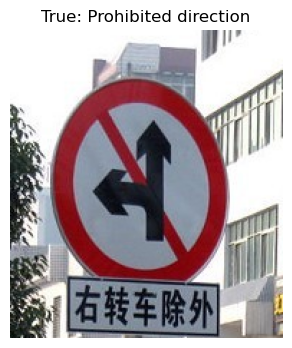

In [71]:
@torch.no_grad()
def predict_image(image_path, model, transform, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    outputs = model(tensor)
    probabilities = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()
    predicted_class = int(np.argmax(probabilities))
    return predicted_class, probabilities

# Try prediction on ten random test images.
for i in range(10):
    sample_row = test_df.sample(1, random_state=random.randint(1, 3869)).iloc[0]
    pred_class, probs = predict_image(sample_row["image_path"], model, val_test_transform, DEVICE)

    print("Image path:", sample_row["image_path"])
    print("True group:", sample_row["GroupedName"])
    print("Predicted group:", class_names[pred_class])
    print("Probabilities:")
    for i, p in enumerate(probs):
        print(f"  {class_names[i]}: {p:.4f}")

    img = Image.open(sample_row["image_path"]).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {sample_row['GroupedName']}")
    Pred: {class_names[pred_class]}
    plt.axis("off")
    plt.show()